In [4]:
from glob import glob
import pickle as pk
import numpy as np
import dfibers.fixed_points as fx
from ising_finder import get_loss_factory
import torch as tr

def kron_prod(op_list):
    """Calculates the Kronecker product of a list of operators."""
    result = op_list[0]
    for op in op_list[1:]:
        result = tr.kron(result, op)
    return result


pauli = [
    tr.tensor([[1.0, 0.0], [0.0, 1.0]], dtype=tr.complex128),
    tr.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=tr.complex128),
    tr.tensor([[0.0, -1j], [1j, 0.0]], dtype=tr.complex128),
    tr.tensor([[1.0, 0.0], [0.0, -1.0]], dtype=tr.complex128),
]

# number of qubits
n_qb = 3
# initial params
h=1.5; J = 1
initial_params = tr.tensor([[0, 0, J, h, 0, 0, 0, 0, 0, h, 0, 0]])

def get_Hamiltonian(c):
    """Creates the general ising Hamiltonian with boundary terms"""
    # c = [K,12], K is batch size
    K = c.shape[0]
    I_list = [pauli[0]] * n_qb
    H = tr.zeros((K, 2**n_qb, 2**n_qb), dtype=tr.complex128)

    # Interaction terms and Single Site terms
    for i in range(n_qb - 1):
        for p in range(1, 4):
            interaction_list = I_list[:]
            interaction_list[i] = pauli[p]
            interaction_list[i + 1] = pauli[p]

            single_term = I_list[:]
            single_term[i] = pauli[p]

            H += c[:, p - 1].view(K, 1, 1) * kron_prod(interaction_list) + c[
                :, 3 + p - 1
            ].view(K, 1, 1) * kron_prod(single_term)

    # Boundary Terms
    for p in range(1, 4):
        site_one = I_list[:]
        site_one[0] = pauli[p]

        site_N = I_list[:]
        site_N[n_qb - 1] = pauli[p]

        H += c[None, :, 6 + p - 1].view(K, 1, 1) * kron_prod(site_one) + c[
            None, :, 9 + p - 1
        ].view(K, 1, 1) * kron_prod(site_N)

    return H


def get_spectrum(c):
    # c is (K, 12) tensor, K is batch size
    H = get_Hamiltonian(c)
    try:
        spectrum = tr.linalg.eigvalsh(H)  # (K, 2**n_qb)
    except tr._C._LinAlgError:
        print("Erorr computing eigenvalues")
        with open("ErrorHamiltonian.txt", "w") as f:
            f.write(str(H))
            f.write("__________________________________\n")
        return np.inf
    return spectrum

init_spectrum = get_spectrum(initial_params)

def compute_diff_spectrum(R_i):
    lambda_i = get_spectrum(R_i)
    diff = tr.sum((lambda_i - init_spectrum) ** 2, dim=1)

    return diff


In [32]:
initial_starting_points = []
image_vectors:np.ndarray = np.empty((12,0))

image_vectors:np.ndarray

file_list = []
file_list.extend(glob("results/ising_random_dirs_3_qubit3/0.pkl"))


for file in file_list:
    with open(file, "rb") as f:
        (c_dir,c_targ, V, A, R) = pk.load(f)

        # Add initial starting point
        initial_starting_points.append(c_targ)
        get_loss = get_loss_factory(c_targ)

        # Filter duplicate points and high-loss points
        duplicates = lambda U, v: (np.fabs(U - v) < 0.1).all(axis=0)
        R_init:np.ndarray = R.copy()
        R = fx.get_unique_points(R, duplicates)


        loss = get_loss(tr.tensor(R.T))
        print(loss)
        keep = loss.numpy() < 1e-10

        # Trim arrays
        R = R[:, keep]
        print(f"Kept {R.shape[1]} points out of {R_init.shape[1]} for file {file}")
        # Store resulting trimmed results
        image_vectors = np.concatenate(
            (image_vectors, R.reshape(12,R.shape[1])), axis=1
        )

# Convert to numpy arrays
initial_starting_points = np.array(initial_starting_points)
image_vectors = np.array(image_vectors)

print(image_vectors.shape[1])


tensor([9.1739e-16, 1.9197e-15, 1.2717e-15, 2.2358e-25, 1.2778e-20, 3.2975e-26, 9.3085e-18, 5.8581e-19, 4.6011e-16, 1.4726e-16, 1.1481e-15, 1.9546e-20, 1.0504e-15, 7.3195e-20, 3.3760e-17, 2.1299e-15, 1.5010e-14, 5.6081e-16, 1.3113e-20, 2.3514e-17, 2.6542e-18, 3.9040e-16, 2.4308e-24, 1.7311e-15, 1.0995e-29, 2.3489e-21, 4.0102e-20, 8.9321e-22, 1.5904e-25, 1.9293e-20, 1.3289e-26, 1.0259e-19, 1.8652e-29, 4.7926e-29, 2.2387e-29, 7.6411e-23, 4.0692e-24, 3.5653e-30, 1.9539e-23, 5.4049e-30, 1.6301e-29, 8.5446e-20, 9.3930e-23, 4.4955e-22, 4.5323e-29, 4.8960e-27, 5.6454e-23, 1.9770e-19, 4.2960e-26, 1.1913e-29, 1.4658e-25, 2.6253e-23, 2.1178e-22, 9.7551e-21, 2.3224e-20, 2.1181e-25, 5.7314e-24, 7.8023e-30, 2.3204e-30, 1.6717e-29, 3.9104e-29, 6.6098e-30, 1.1206e-23, 9.8145e-30, 1.1882e-29, 3.1288e-24, 1.3164e-29, 1.7907e-26, 1.4590e-23, 9.0831e-27, 4.8287e-20, 2.9385e-23, 6.2840e-24, 1.6707e-20, 2.5391e-30, 2.5200e-29, 7.8285e-29, 4.2552e-29, 2.1225e-25, 1.2374e-22, 4.3665e-29, 6.6548e-13,
        

Text(0.5, 1.0, 'Loss along fiber for random direction')

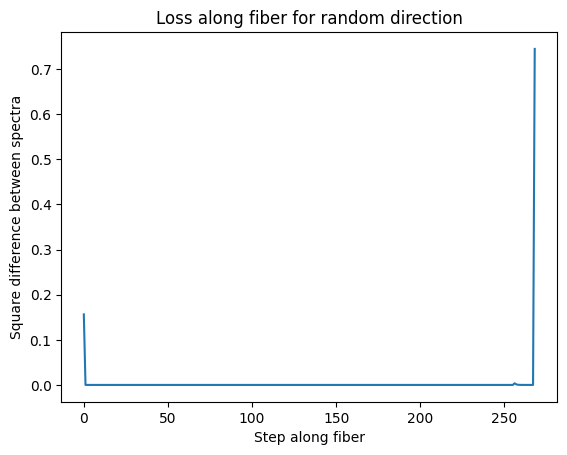

In [28]:
plt.plot(get_loss(tr.tensor(V.T)))
plt.xlabel("Step along fiber")
plt.ylabel("Square difference between spectra")
plt.title("Loss along fiber for random direction")

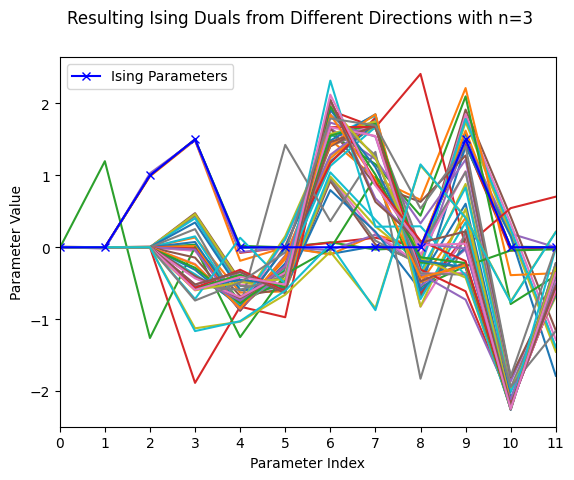

In [31]:
import matplotlib.pyplot as plt

slice = range(0,image_vectors.shape[1])

#for i in slice:
#    print(f"Plotting image vector {i} with loss {compute_diff_spectrum(tr.tensor(image_vectors[:,i:i+1]).reshape(1,12,1))}")
#print(image_vectors[:, slice])

plt.plot(image_vectors[:, slice])
plt.plot(initial_params.T, "bx-", label="Ising Parameters")
plt.xlim(0,11)
plt.xticks(range(12))
plt.suptitle("Resulting Ising Duals from Different Directions with n=3")
plt.xlabel("Parameter Index")
plt.ylabel("Parameter Value")
plt.legend()
plt.show()

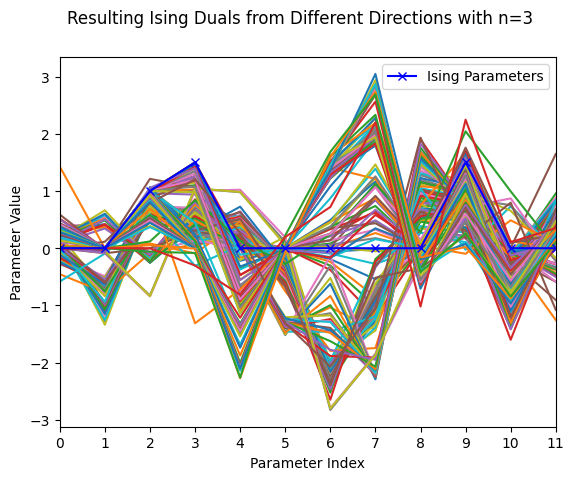

In [33]:
import matplotlib.pyplot as plt

slice = range(0,image_vectors.shape[1])

#for i in slice:
#    print(f"Plotting image vector {i} with loss {compute_diff_spectrum(tr.tensor(image_vectors[:,i:i+1]).reshape(1,12,1))}")
#print(image_vectors[:, slice])

plt.plot(image_vectors[:, slice])
plt.plot(initial_params.T, "bx-", label="Ising Parameters")
plt.xlim(0,11)
plt.xticks(range(12))
plt.suptitle("Resulting Ising Duals from Different Directions with n=3")
plt.xlabel("Parameter Index")
plt.ylabel("Parameter Value")
plt.legend()
plt.show()

In [23]:
print(V.shape)
print(get_loss(tr.tensor(V.T)))
print(V[:,0]/np.linalg.norm(V[:,0]))
print(V[:,-1]/np.linalg.norm(V[:,-1]))

(12, 193)
tensor([2.5579e+03, 3.0583e-19, 4.3112e-19, 7.5006e-20, 1.8886e-29, 2.0311e-23, 1.4975e-24, 1.2232e-27, 2.5438e-19, 3.5796e-22, 2.4629e-26, 6.9096e-23, 1.0435e-22, 9.4252e-21, 7.9959e-23, 2.5650e-17, 4.4756e-28, 3.8464e-27, 2.0098e-23, 2.9509e-14, 2.7701e-17, 3.8011e-18, 3.5148e-18, 5.5455e-15, 3.4276e-22, 4.3484e-16, 1.4922e-25, 6.0238e-22, 1.5853e-14, 1.8264e-15, 4.5781e-20, 1.7119e-18, 3.0558e-17, 4.8334e-23, 1.4814e-21, 2.3602e-26, 7.6280e-21, 3.8239e-28, 2.1041e-26, 1.4559e-19, 4.0025e-28, 5.8965e-23, 1.8046e-16, 6.6289e-18, 2.3612e-26, 1.1026e-26, 7.0092e-29, 1.2597e-23, 1.2455e-29, 5.9515e-22, 1.2004e-24, 7.8767e-24, 8.1648e-27, 7.7129e-23, 1.0119e-18, 2.6989e-22, 5.6065e-28, 1.4143e-25, 5.1478e-23, 1.1126e-23, 2.1868e-14, 3.9241e-16, 2.0779e-14, 2.2755e-20, 4.3535e-22, 1.6804e-28, 1.7083e-15, 3.8436e-16, 9.2728e-18, 7.5826e-16, 3.1697e-18, 2.1410e-17, 2.7298e-13, 6.3293e-14, 0.0000e+00, 0.0000e+00, 8.3917e-21, 3.9920e-15, 2.9476e-15, 2.0325e-29, 1.4895e-17, 7.9045e-27

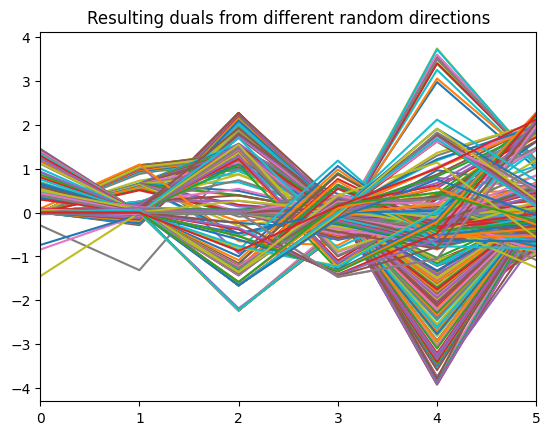

In [45]:
filtered_image_vectors = image_vectors[[0,1,3,4,6,7,9,10],:]
"""
Remove the constant values to determine what is truly changing in the data.
Removed: \sigma_z \sigma_z, \sigma_z^i, \sigma_z^0, \sigma_z^n
"""
plt.plot(filtered_image_vectors)
plt.xlim(0,5)
plt.xticks(range(6))
plt.title("Resulting duals from different random directions")

plt.show()